In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import simpy

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

LAMBDA1 = 3.0
LAMBDA2 = 5.0
MU = 10.0
print("lambda1, lambda2, mu:", LAMBDA1, LAMBDA2, MU)

lambda1, lambda2, mu: 3.0 5.0 10.0


In [15]:
def mm1_np_priority_metrics(
    lambda1: float,
    lambda2: float,
    mu: float,
    mu_high_factor: float = 1.5,
) -> dict | None:
    mu1 = mu * mu_high_factor
    mu2 = mu

    rho1 = lambda1 / mu1
    rho2 = lambda2 / mu2
    rho = rho1 + rho2
    if rho1 >= 1.0 or rho >= 1.0:
        return None

    wq1 = lambda1 / (mu1**2 * (1.0 - rho1))
    wq2 = (lambda1 / mu1**2 + lambda2 / mu2**2) / ((1.0 - rho1) * (1.0 - rho))

    w1 = wq1 + 1.0 / mu1
    w2 = wq2 + 1.0 / mu2

    l1 = lambda1 * w1
    l2 = lambda2 * w2
    l_tot = l1 + l2


    p_wait1_theory = rho1
    p_wait2_theory = rho

    return {
        "lambda1": lambda1,
        "lambda2": lambda2,
        "mu1": mu1,
        "mu2": mu2,
        "rho1": rho1,
        "rho2": rho2,
        "rho": rho,
        "Wq1": wq1,
        "Wq2": wq2,
        "W1": w1,
        "W2": w2,
        "L1": l1,
        "L2": l2,
        "L": l_tot,
        "P_wait1_theory": p_wait1_theory,
        "P_wait2_theory": p_wait2_theory,
    }


base = mm1_np_priority_metrics(LAMBDA1, LAMBDA2, MU)
print(pd.Series(base))

lambda1            3.000000
lambda2            5.000000
mu1               15.000000
mu2               10.000000
rho1               0.200000
rho2               0.500000
rho                0.700000
Wq1                0.016667
Wq2                0.263889
W1                 0.083333
W2                 0.363889
L1                 0.250000
L2                 1.819444
L                  2.069444
P_wait1_theory     0.200000
P_wait2_theory     0.700000
dtype: float64


In [16]:
rows = []
if base is not None:
    rows.append(
        {
            "класс": "1 (высокий)",
            "Wq": base["Wq1"],
            "W": base["W1"],
            "P_wait (теор.)": base["P_wait1_theory"],
            "L": base["L1"],
        }
    )
    rows.append(
        {
            "класс": "2 (низкий)",
            "Wq": base["Wq2"],
            "W": base["W2"],
            "P_wait (теор.)": base["P_wait2_theory"],
            "L": base["L2"],
        }
    )
df_theory_classes = pd.DataFrame(rows)
df_system = pd.DataFrame([{"rho": base["rho"], "L (вся система)": base["L"]}])

print("Теория по классам:")
print(df_theory_classes)
print("Система:")
print(df_system)

Теория по классам:
         класс        Wq         W  P_wait (теор.)         L
0  1 (высокий)  0.016667  0.083333             0.2  0.250000
1   2 (низкий)  0.263889  0.363889             0.7  1.819444
Система:
   rho  L (вся система)
0  0.7         2.069444


In [17]:
def simulate_mm1_np_priority(
    lambda1: float,
    lambda2: float,
    mu: float,
    sim_time: float = 80_000.0,
    warmup: float = 8_000.0,
    seed: int = 42,
) -> dict:
    env = simpy.Environment()
    server = simpy.PreemptiveResource(env, capacity=1)
    rng = np.random.default_rng(seed)

    mu_high = mu * 1.5
    mu_low = mu

    stats = {
        "n1": 0,
        "n2": 0,
        "waited1": 0,
        "waited2": 0,
        "sum_wq1": 0.0,
        "sum_wq2": 0.0,
        "sum_w1": 0.0,
        "sum_w2": 0.0,
    }

    def customer(class_id: int):
        arrival = env.now
        pr = 0 if class_id == 1 else 1
        mu_cls = mu_high if class_id == 1 else mu_low

        service_time = rng.exponential(1.0 / mu_cls)
        remaining = service_time
        first_start = None

        while remaining > 1e-12:
            with server.request(priority=pr, preempt=True) as req:
                yield req
                if first_start is None:
                    first_start = env.now
                started = env.now
                try:
                    yield env.timeout(remaining)
                    remaining = 0.0
                except simpy.Interrupt:
                    served = env.now - started
                    remaining = max(0.0, remaining - served)

        if arrival < warmup:
            return

        sojourn = env.now - arrival
        wait_total = max(0.0, sojourn - service_time)
        wait_first = max(0.0, (first_start - arrival) if first_start is not None else 0.0)
        eps = 1e-9

        if class_id == 1:
            stats["n1"] += 1
            stats["sum_wq1"] += wait_total
            stats["sum_w1"] += sojourn
            if wait_first > eps:
                stats["waited1"] += 1
        else:
            stats["n2"] += 1
            stats["sum_wq2"] += wait_total
            stats["sum_w2"] += sojourn
            if wait_first > eps:
                stats["waited2"] += 1

    def arrivals_class(lam: float, class_id: int):
        while True:
            yield env.timeout(rng.exponential(1.0 / lam))
            env.process(customer(class_id))

    env.process(arrivals_class(lambda1, 1))
    env.process(arrivals_class(lambda2, 2))
    env.run(until=sim_time)

    n1, n2 = stats["n1"], stats["n2"]
    return {
        "Wq1": stats["sum_wq1"] / n1 if n1 else np.nan,
        "Wq2": stats["sum_wq2"] / n2 if n2 else np.nan,
        "W1": stats["sum_w1"] / n1 if n1 else np.nan,
        "W2": stats["sum_w2"] / n2 if n2 else np.nan,
        "P_wait1": stats["waited1"] / n1 if n1 else np.nan,
        "P_wait2": stats["waited2"] / n2 if n2 else np.nan,
        "n1": n1,
        "n2": n2,
    }

sim_base = simulate_mm1_np_priority(LAMBDA1, LAMBDA2, MU, sim_time=80_000, warmup=8_000, seed=42)
th = mm1_np_priority_metrics(LAMBDA1, LAMBDA2, MU)

compare = pd.DataFrame(
    {
        "metric": ["Wq1", "Wq2", "W1", "W2", "P_wait1", "P_wait2"],
        "theory": [th["Wq1"], th["Wq2"], th["W1"], th["W2"], th["P_wait1_theory"], th["P_wait2_theory"]],
        "simulation": [
            sim_base["Wq1"],
            sim_base["Wq2"],
            sim_base["W1"],
            sim_base["W2"],
            sim_base["P_wait1"],
            sim_base["P_wait2"],
        ],
    }
)
compare["abs_err"] = (compare["simulation"] - compare["theory"]).abs()
compare["rel_err_%"] = np.where(
    np.isfinite(compare["theory"]) & (compare["theory"] != 0),
    compare["abs_err"] / np.abs(compare["theory"]) * 100.0,
    np.nan,
)

print("Заявок после warmup: класс 1 =", sim_base["n1"], ", класс 2 =", sim_base["n2"])
print(compare)

Заявок после warmup: класс 1 = 216332 , класс 2 = 360235
    metric    theory  simulation   abs_err  rel_err_%
0      Wq1  0.016667    0.016561  0.000106   0.635826
1      Wq2  0.263889    0.285902  0.022013   8.341908
2       W1  0.083333    0.083064  0.000269   0.323186
3       W2  0.363889    0.385812  0.021924   6.024780
4  P_wait1  0.200000    0.199587  0.000413   0.206627
5  P_wait2  0.700000    0.698272  0.001728   0.246863


In [18]:
def sweep_lambda1(lambda2_fixed: float, mu: float, grid):
    rows = []
    for i, l1 in enumerate(grid):
        if l1 < 0:
            continue
        t = mm1_np_priority_metrics(l1, lambda2_fixed, mu)
        if t is None:
            continue
        s = simulate_mm1_np_priority(l1, lambda2_fixed, mu, sim_time=80_000, warmup=8_000, seed=500 + i)
        rows.append(
            {
                "lambda1": l1,
                "Wq1_theory": t["Wq1"],
                "Wq2_theory": t["Wq2"],
                "Wq1_sim": s["Wq1"],
                "Wq2_sim": s["Wq2"],
                "rho": t["rho"],
            }
        )
    return pd.DataFrame(rows)


def sweep_lambda2(lambda1_fixed: float, mu: float, grid):
    rows = []
    for i, l2 in enumerate(grid):
        if l2 < 0:
            continue
        t = mm1_np_priority_metrics(lambda1_fixed, l2, mu)
        if t is None:
            continue
        s = simulate_mm1_np_priority(lambda1_fixed, l2, mu, sim_time=80_000, warmup=8_000, seed=700 + i)
        rows.append(
            {
                "lambda2": l2,
                "Wq1_theory": t["Wq1"],
                "Wq2_theory": t["Wq2"],
                "Wq1_sim": s["Wq1"],
                "Wq2_sim": s["Wq2"],
                "rho": t["rho"],
            }
        )
    return pd.DataFrame(rows)

g1 = np.linspace(0.1, 4.5, 12)
df_s1 = sweep_lambda1(LAMBDA2, MU, g1)

g2 = np.linspace(0.1, 4.5, 12)
df_s2 = sweep_lambda2(LAMBDA1, MU, g2)
print("Сетка по λ1 (первые строки):")
print(df_s1.head())
print("Сетка по λ2 (первые строки):")
print(df_s2.head())

Сетка по λ1 (первые строки):
   lambda1  Wq1_theory  Wq2_theory   Wq1_sim   Wq2_sim       rho
0      0.1    0.000447    0.102939  0.000433  0.104129  0.506667
1      0.5    0.002299    0.115764  0.002037  0.118659  0.533333
2      0.9    0.004255    0.130561  0.004169  0.137276  0.560000
3      1.3    0.006326    0.147751  0.006253  0.157507  0.586667
4      1.7    0.008521    0.167877  0.008164  0.180317  0.613333
Сетка по λ2 (первые строки):
   lambda2  Wq1_theory  Wq2_theory   Wq1_sim   Wq2_sim   rho
0      0.1    0.016667    0.022679  0.016861  0.047647  0.21
1      0.5    0.016667    0.030556  0.016666  0.054384  0.25
2      0.9    0.016667    0.039319  0.016611  0.064041  0.29
3      1.3    0.016667    0.049129  0.016646  0.073980  0.33
4      1.7    0.016667    0.060185  0.016422  0.084810  0.37


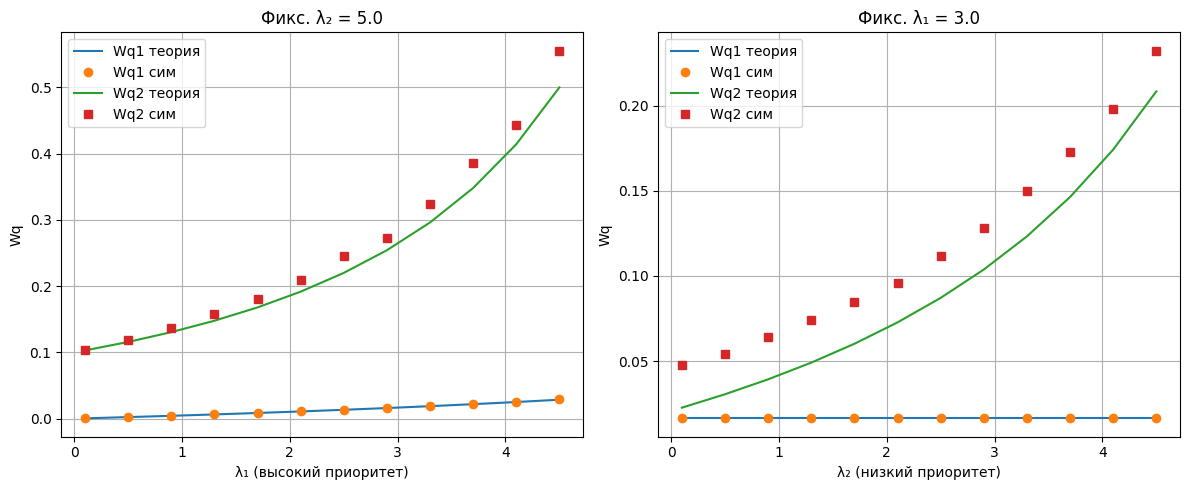

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(df_s1["lambda1"], df_s1["Wq1_theory"], "-", label="Wq1 теория")
ax[0].plot(df_s1["lambda1"], df_s1["Wq1_sim"], "o", label="Wq1 сим")
ax[0].plot(df_s1["lambda1"], df_s1["Wq2_theory"], "-", label="Wq2 теория")
ax[0].plot(df_s1["lambda1"], df_s1["Wq2_sim"], "s", label="Wq2 сим")
ax[0].set_xlabel("λ₁ (высокий приоритет)")
ax[0].set_ylabel("Wq")
ax[0].set_title(f"Фикс. λ₂ = {LAMBDA2}")
ax[0].legend()

ax[1].plot(df_s2["lambda2"], df_s2["Wq1_theory"], "-", label="Wq1 теория")
ax[1].plot(df_s2["lambda2"], df_s2["Wq1_sim"], "o", label="Wq1 сим")
ax[1].plot(df_s2["lambda2"], df_s2["Wq2_theory"], "-", label="Wq2 теория")
ax[1].plot(df_s2["lambda2"], df_s2["Wq2_sim"], "s", label="Wq2 сим")
ax[1].set_xlabel("λ₂ (низкий приоритет)")
ax[1].set_ylabel("Wq")
ax[1].set_title(f"Фикс. λ₁ = {LAMBDA1}")
ax[1].legend()

plt.tight_layout()
plt.show()